In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
df = pd.read_csv('../data/processed/cleaned_data.csv')


In [6]:
customer_data = pd.read_csv('../data/processed/customer_analysis.csv')
monthly_data = pd.read_csv('../data/processed/monthly_trend.csv')
product_data = pd.read_csv('../data/processed/product_performance.csv')
regional_data = pd.read_csv('../data/processed/regional_analysis.csv')
sales_summary = pd.read_csv('../data/processed/sales_summary.csv')


In [7]:
print(f"Main dataset: {df.shape[0]} rows")
print(f"Customer analysis: {customer_data.shape[0]} rows")
print(f"Monthly trends: {monthly_data.shape[0]} rows")
print(f"Product performance: {product_data.shape[0]} rows")
print(f"Regional analysis: {regional_data.shape[0]} rows")


Main dataset: 51290 rows
Customer analysis: 4873 rows
Monthly trends: 48 rows
Product performance: 3 rows
Regional analysis: 147 rows


In [8]:
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset: 51290 rows, 35 columns


Text(0.5, 1.0, 'Monthly Sales Trend')

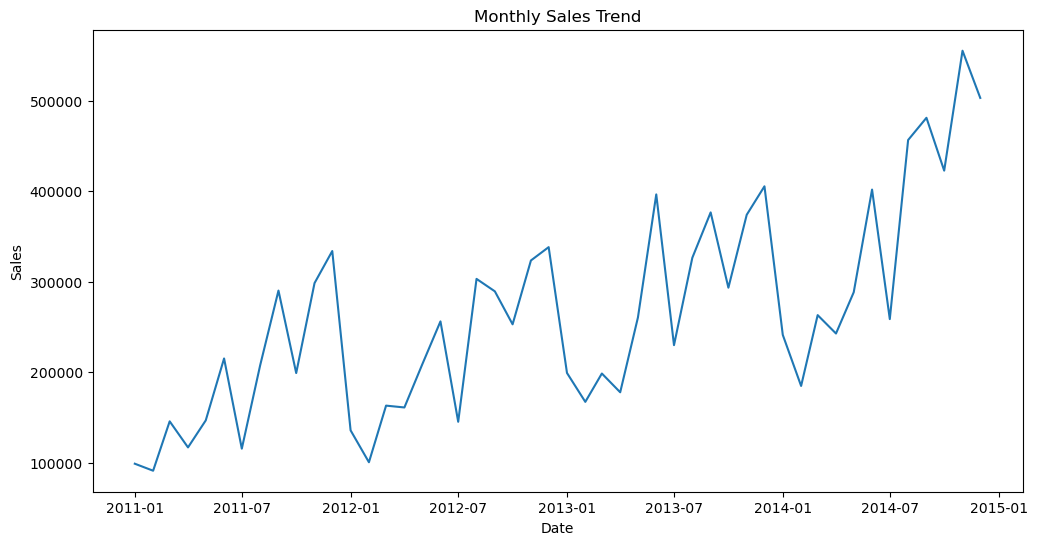

In [4]:
# Line chart: Monthly Sales
monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(day=1))
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Sales', data=monthly)
plt.title("Monthly Sales Trend")

<Axes: ylabel='Sales'>

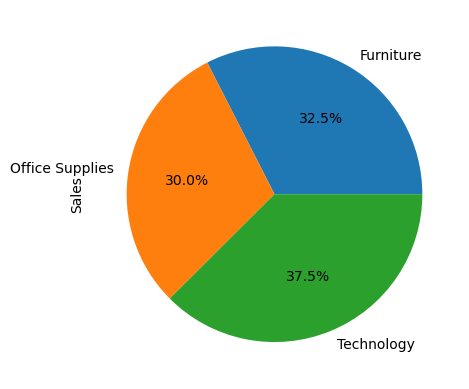

In [5]:
# Pie: Category Sales Share
df.groupby('Category')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')

([0, 1, 2],
 [Text(0, 0, 'Technology'),
  Text(1, 0, 'Furniture'),
  Text(2, 0, 'Office Supplies')])

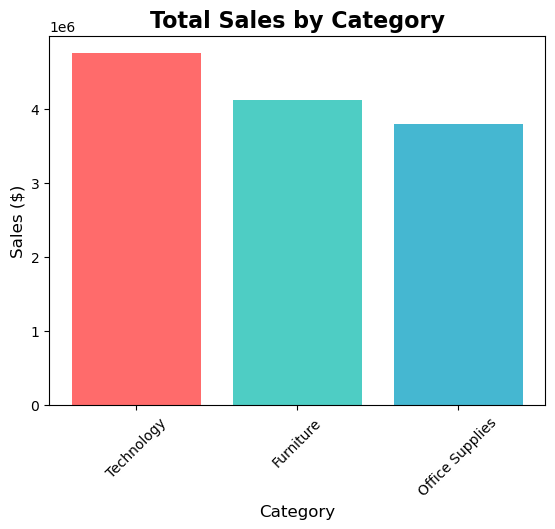

In [11]:
# Try using category analysis data first, fallback to main dataset
try:
    if 'Category' in product_data.columns and 'Sales' in product_data.columns:
        category_sales = product_data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
    else:
        category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
except:
    category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Create bar chart
plt.bar(category_sales.index, category_sales.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=45)



4. 📊 HISTOGRAM: Sales Distribution


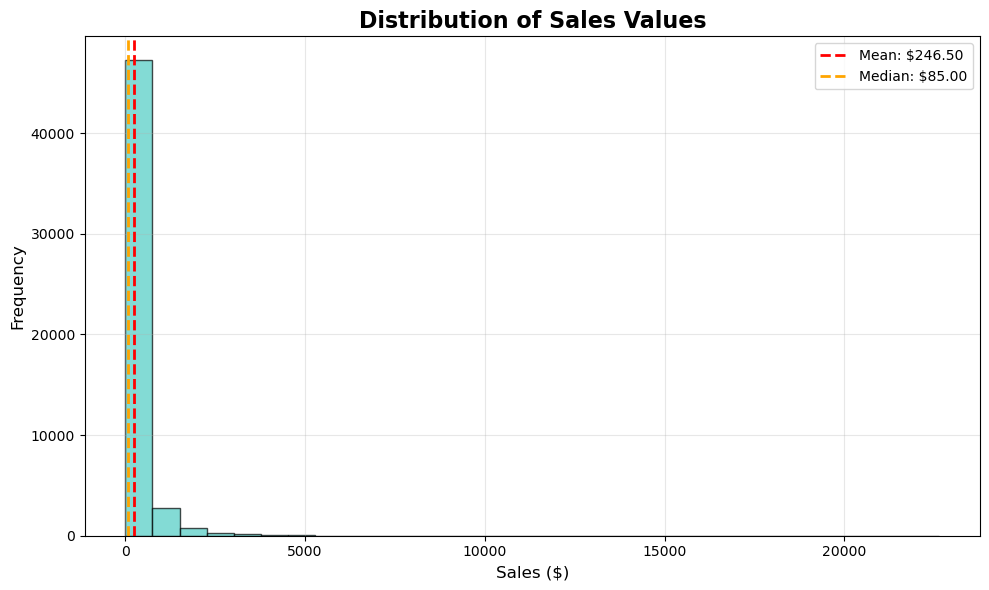

In [ ]:
# HISTOGRAM - Sales Distribution
print("\n4. 📊 HISTOGRAM: Sales Distribution")
plt.figure(figsize=(10, 6))

plt.hist(df['Sales'], bins=30, alpha=0.7, color='#4ECDC4', edgecolor='black')
plt.title('Distribution of Sales Values', fontsize=16, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Add statistics
mean_sales = df['Sales'].mean()
median_sales = df['Sales'].median()
plt.axvline(mean_sales, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_sales:.2f}')
plt.axvline(median_sales, color='orange', linestyle='--', linewidth=2, label=f'Median: ${median_sales:.2f}')
plt.legend()

plt.tight_layout()
plt.show()


5. ⚡ SCATTER PLOT: Sales vs Profit


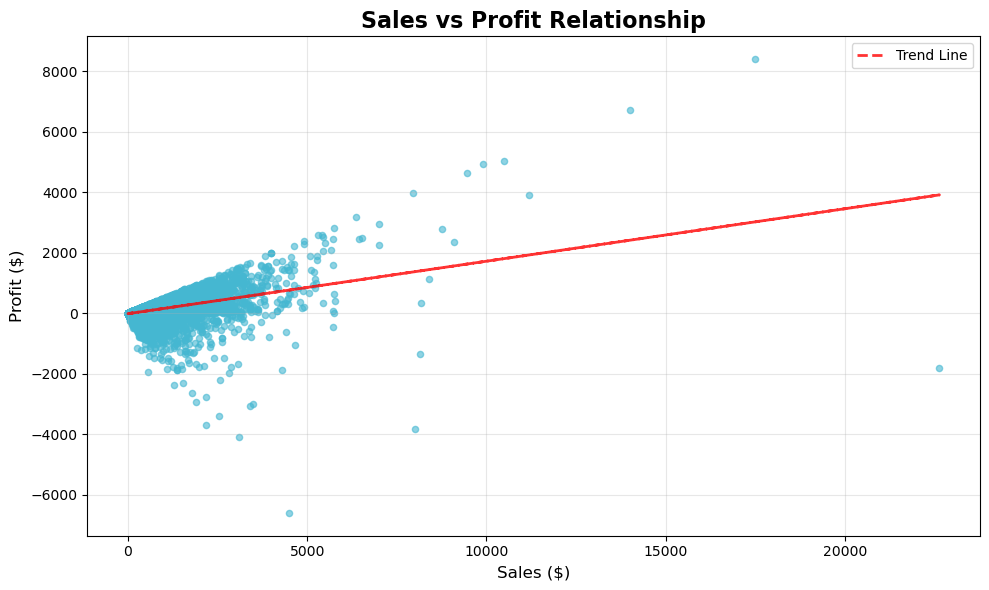

In [15]:
# SCATTER PLOT - Sales vs Profit
print("\n5. ⚡ SCATTER PLOT: Sales vs Profit")
plt.figure(figsize=(10, 6))

plt.scatter(df['Sales'], df['Profit'], alpha=0.6, color='#45B7D1', s=20)
plt.title('Sales vs Profit Relationship', fontsize=16, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['Sales'], df['Profit'], 1)
p = np.poly1d(z)
plt.plot(df['Sales'], p(df['Sales']), "r--", alpha=0.8, linewidth=2, label='Trend Line')
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/2d/6kky53r90h312l6jvp5rdjh80000gn/T/ipykernel_60368/3498339148.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot([df[df['Category'] == cat]['Profit'] for cat in df['Category'].unique()],


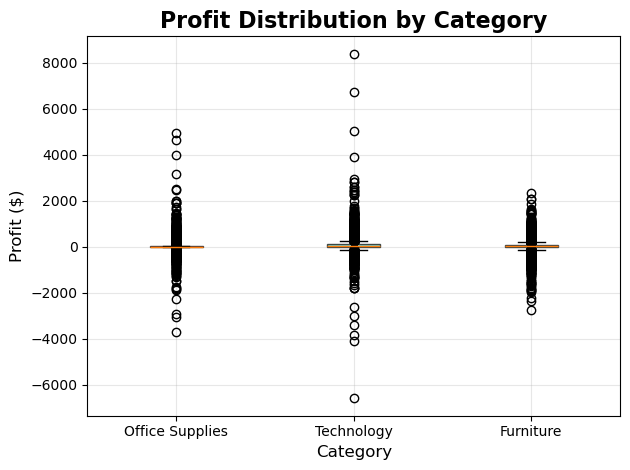

In [16]:
# Create box plot
box_plot = plt.boxplot([df[df['Category'] == cat]['Profit'] for cat in df['Category'].unique()], 
                       labels=df['Category'].unique(), patch_artist=True)

# Color the boxes
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Profit Distribution by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


8. 🔥 HEATMAP: Sales by Month and Category


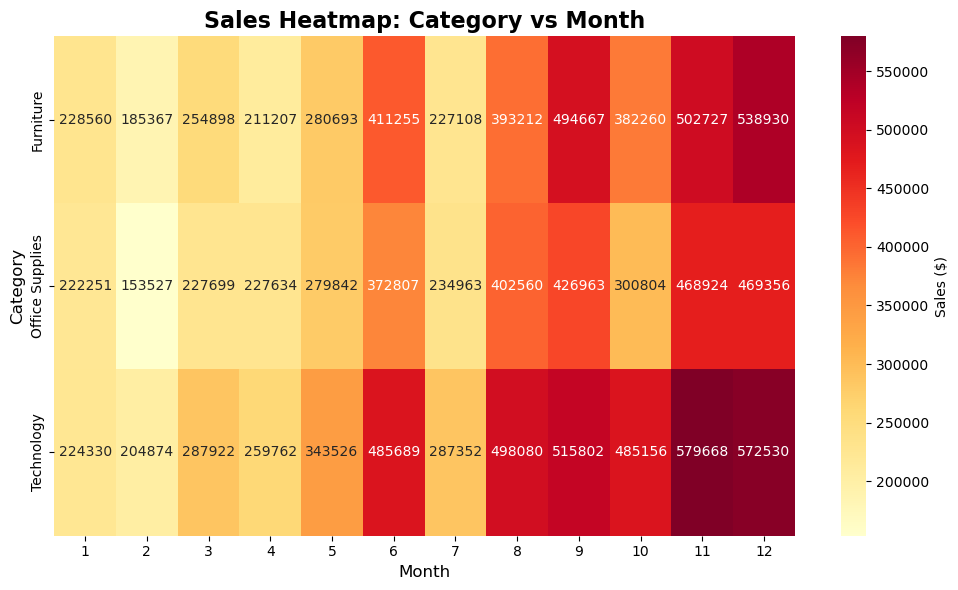

In [19]:
#  SIMPLE HEATMAP - Sales by Month and Category
print("\n8. 🔥 HEATMAP: Sales by Month and Category")
plt.figure(figsize=(10, 6))

# Create pivot table
heatmap_data = df.pivot_table(values='Sales', index='Category', columns='Month', aggfunc='sum')

# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Sales ($)'})
plt.title('Sales Heatmap: Category vs Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()